# 💳 Financial Fraud Detection — Complete EDA
## 1M Transactions · 7 Fraud Types · 200 Fraud Rings · March 2022–2024

**Dataset:** Financial Fraud Detection Dataset  
**Author:** Sergey Nefedov | [github.com/Sergpreneur](https://github.com/Sergpreneur)

---

### What this notebook covers
1. 📊 Dataset overview — class imbalance, fraud rate, feature distributions
2. ⏰ Temporal patterns — when does fraud peak? (hour × day heatmap)
3. 💰 Amount & geography — how much do fraudsters spend?
4. 🔍 Fraud pattern deep-dive — 7 types compared across all dimensions
5. 🕸️ Network analysis — fraud rings, connection types, degree distribution
6. 🤖 ML model — LightGBM with SMOTE, PR-AUC, SHAP feature importance

> **Key insight:** Fraud is not random — it clusters by time (00:00–05:00), geography  
> (foreign transactions 4× higher rate), and merchant type (crypto/gambling 3–5×).  
> Understanding the pattern is more valuable than the model accuracy alone.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.facecolor': '#0d1117', 'figure.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e', 'text.color': '#c9d1d9',
    'grid.color': '#21262d', 'grid.alpha': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False,
})
RED='#f85149'; GREEN='#3fb950'; BLUE='#388bfd'; AMBER='#f7931a'
PURPLE='#9945ff'; TEAL='#39d353'; GRAY='#8b949e'

PAT_COLORS = {
    'card_not_present': '#f85149', 'account_takeover': '#f7931a',
    'card_present_stolen': '#ffa657', 'friendly_fraud': '#388bfd',
    'atm_fraud': '#9945ff', 'money_laundering': '#3fb950', 'identity_theft': '#39d353'
}

PATH = '/kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/'

txn      = pd.read_csv(PATH + 'transactions.csv', parse_dates=['timestamp'])
patterns = pd.read_csv(PATH + 'fraud_patterns.csv')
accounts = pd.read_csv(PATH + 'account_profiles.csv')
edges    = pd.read_csv(PATH + 'network_edges.csv')
ts       = pd.read_csv(PATH + 'time_series_stats.csv', parse_dates=['hour'])

fraud = txn[txn['is_fraud'] == 1]
legit = txn[txn['is_fraud'] == 0]

print(f"Transactions:     {len(txn):>10,}")
print(f"Fraudulent:       {len(fraud):>10,}  ({len(fraud)/len(txn):.3%})")
print(f"Legitimate:       {len(legit):>10,}")
print(f"Class imbalance:  {len(legit)//len(fraud):,}:1")
print(f"Accounts:         {txn['account_id'].nunique():>10,}")
print(f"Date range:       {txn['timestamp'].min().date()} → {txn['timestamp'].max().date()}")
print(f"Fraud patterns:   {txn['fraud_pattern'].nunique() - 1} types")
print(f"\nFraud by pattern:")
print(txn[txn['is_fraud']==1]['fraud_pattern'].value_counts().to_string())


Transactions:      1,000,000
Fraudulent:           17,143  (1.714%)
Legitimate:          982,857
Class imbalance:  57:1
Accounts:             49,903
Date range:       2022-01-01 → 2024-12-30
Fraud patterns:   6 types

Fraud by pattern:
fraud_pattern
card_not_present       5982
account_takeover       3432
card_present_stolen    3120
friendly_fraud         1726
atm_fraud              1216
money_laundering       1011
identity_theft          656


---
## 1. 📊 Dataset Overview — Class Imbalance & Feature Distributions

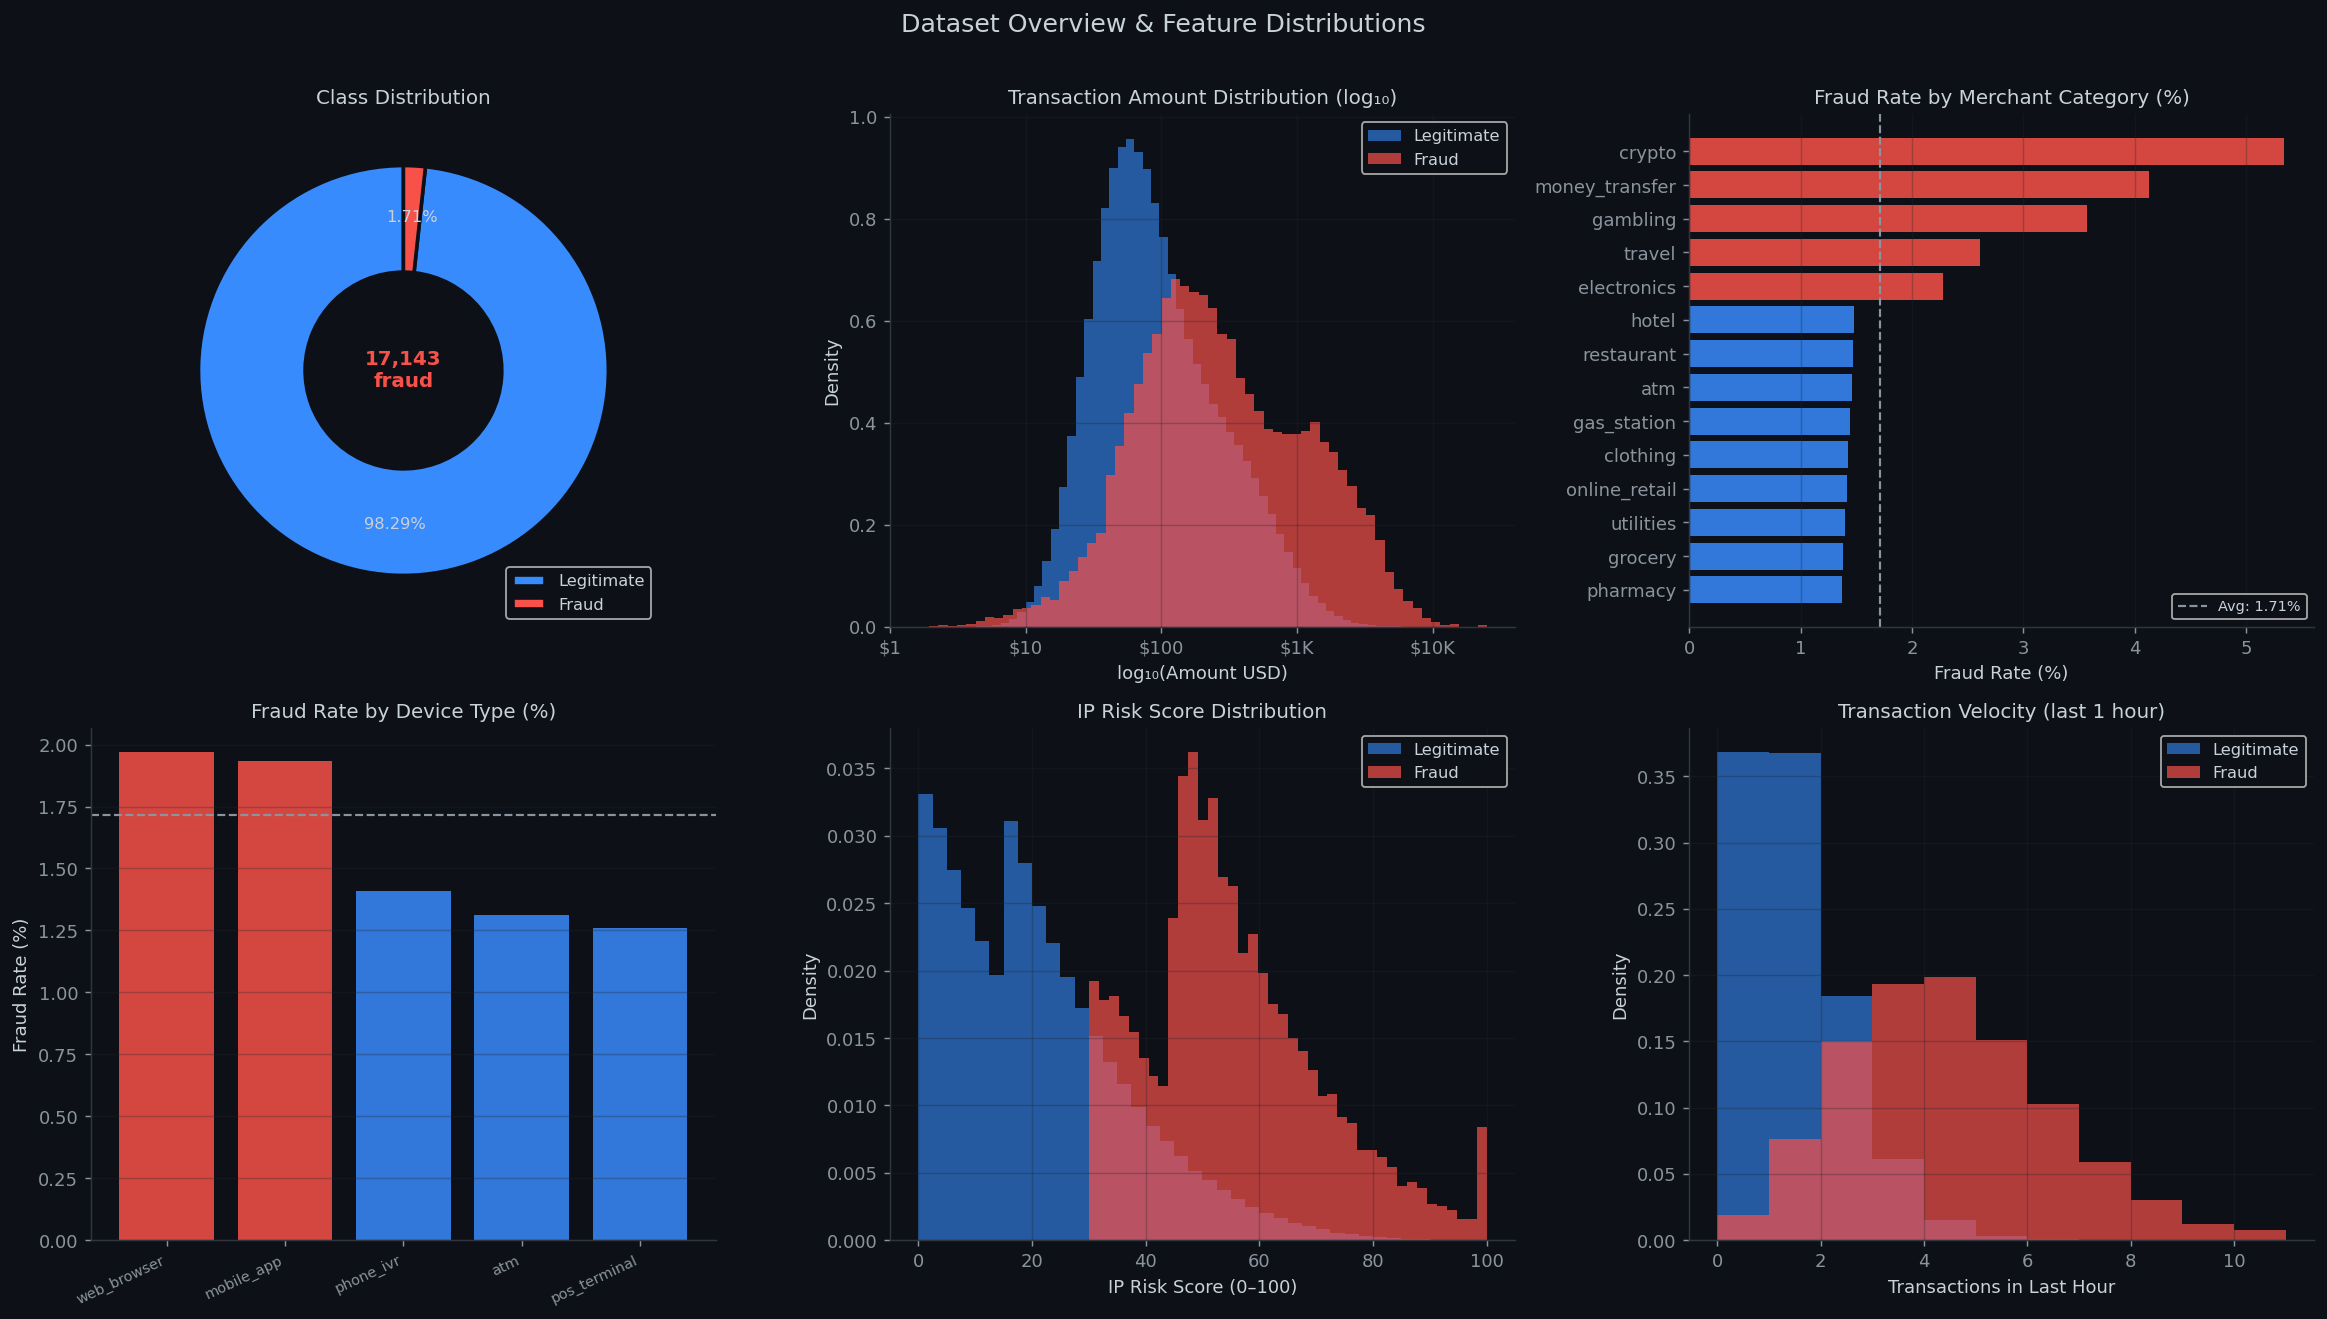


Amount stats:
                         Legitimate          Fraud    Ratio
Mean ($)                     174.21         730.14    4.19x
Median ($)                    80.03         240.74    3.01x
Max ($)                    8,930.27      25,000.00    2.80x


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Class imbalance donut
ax = axes[0,0]
sizes = [len(legit), len(fraud)]
wedges, texts, autotexts = ax.pie(
    sizes, colors=[BLUE, RED], autopct='%1.2f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.52, edgecolor='#0d1117', linewidth=2),
    textprops={'fontsize':9, 'color':'#c9d1d9'})
for at in autotexts: at.set_color('#c9d1d9')
ax.set_title('Class Distribution', fontsize=11)
ax.legend(['Legitimate', 'Fraud'], fontsize=9, loc='lower right')
ax.text(0, 0, f'{len(fraud):,}\nfraud', ha='center', va='center', fontsize=11, color=RED, fontweight='bold')

# Panel 2: Amount distribution (log scale)
ax = axes[0,1]
ax.hist(np.log10(legit['amount'].clip(0.1)), bins=60, alpha=0.6,
        color=BLUE, label='Legitimate', density=True)
ax.hist(np.log10(fraud['amount'].clip(0.1)), bins=60, alpha=0.7,
        color=RED, label='Fraud', density=True)
ax.set_title('Transaction Amount Distribution (log₁₀)', fontsize=11)
ax.set_xlabel('log₁₀(Amount USD)'); ax.set_ylabel('Density')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['$1', '$10', '$100', '$1K', '$10K'])
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: Fraud rate by merchant category
ax = axes[0,2]
cat_fr = txn.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=True) * 100
ax.barh(cat_fr.index, cat_fr.values,
        color=[RED if v > txn['is_fraud'].mean()*100*1.3 else BLUE for v in cat_fr.values],
        alpha=0.85)
ax.axvline(txn['is_fraud'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--',
           label=f'Avg: {txn["is_fraud"].mean():.2%}')
ax.set_title('Fraud Rate by Merchant Category (%)', fontsize=11)
ax.set_xlabel('Fraud Rate (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')

# Panel 4: Device type fraud rate
ax = axes[1,0]
dev_fr = txn.groupby('device_type')['is_fraud'].mean().sort_values(ascending=False) * 100
ax.bar(range(len(dev_fr)), dev_fr.values,
       color=[RED if v > txn['is_fraud'].mean()*100 else BLUE for v in dev_fr.values],
       alpha=0.85)
ax.set_xticks(range(len(dev_fr)))
ax.set_xticklabels(dev_fr.index, rotation=25, ha='right', fontsize=8)
ax.axhline(txn['is_fraud'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--')
ax.set_title('Fraud Rate by Device Type (%)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)'); ax.grid(True, alpha=0.3, axis='y')

# Panel 5: IP risk score distribution
ax = axes[1,1]
ax.hist(legit['ip_risk_score'], bins=40, alpha=0.6, color=BLUE,
        label='Legitimate', density=True)
ax.hist(fraud['ip_risk_score'], bins=40, alpha=0.7, color=RED,
        label='Fraud', density=True)
ax.set_title('IP Risk Score Distribution', fontsize=11)
ax.set_xlabel('IP Risk Score (0–100)'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 6: Velocity distribution
ax = axes[1,2]
ax.hist(legit['velocity_1h'].clip(0, 10), bins=11, range=(0,11), alpha=0.6,
        color=BLUE, label='Legitimate', density=True)
ax.hist(fraud['velocity_1h'].clip(0, 10), bins=11, range=(0,11), alpha=0.7,
        color=RED, label='Fraud', density=True)
ax.set_title('Transaction Velocity (last 1 hour)', fontsize=11)
ax.set_xlabel('Transactions in Last Hour'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Dataset Overview & Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('overview.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\nAmount stats:")
print(f"{'':20s} {'Legitimate':>14s} {'Fraud':>14s} {'Ratio':>8s}")
for name, lv, fv in [
    ('Mean ($)',   legit['amount'].mean(),   fraud['amount'].mean()),
    ('Median ($)', legit['amount'].median(), fraud['amount'].median()),
    ('Max ($)',    legit['amount'].max(),     fraud['amount'].max()),
]:
    print(f"{name:20s} {lv:>14,.2f} {fv:>14,.2f} {fv/lv:>7.2f}x")


---
## 2. ⏰ Temporal Patterns — When Does Fraud Strike?

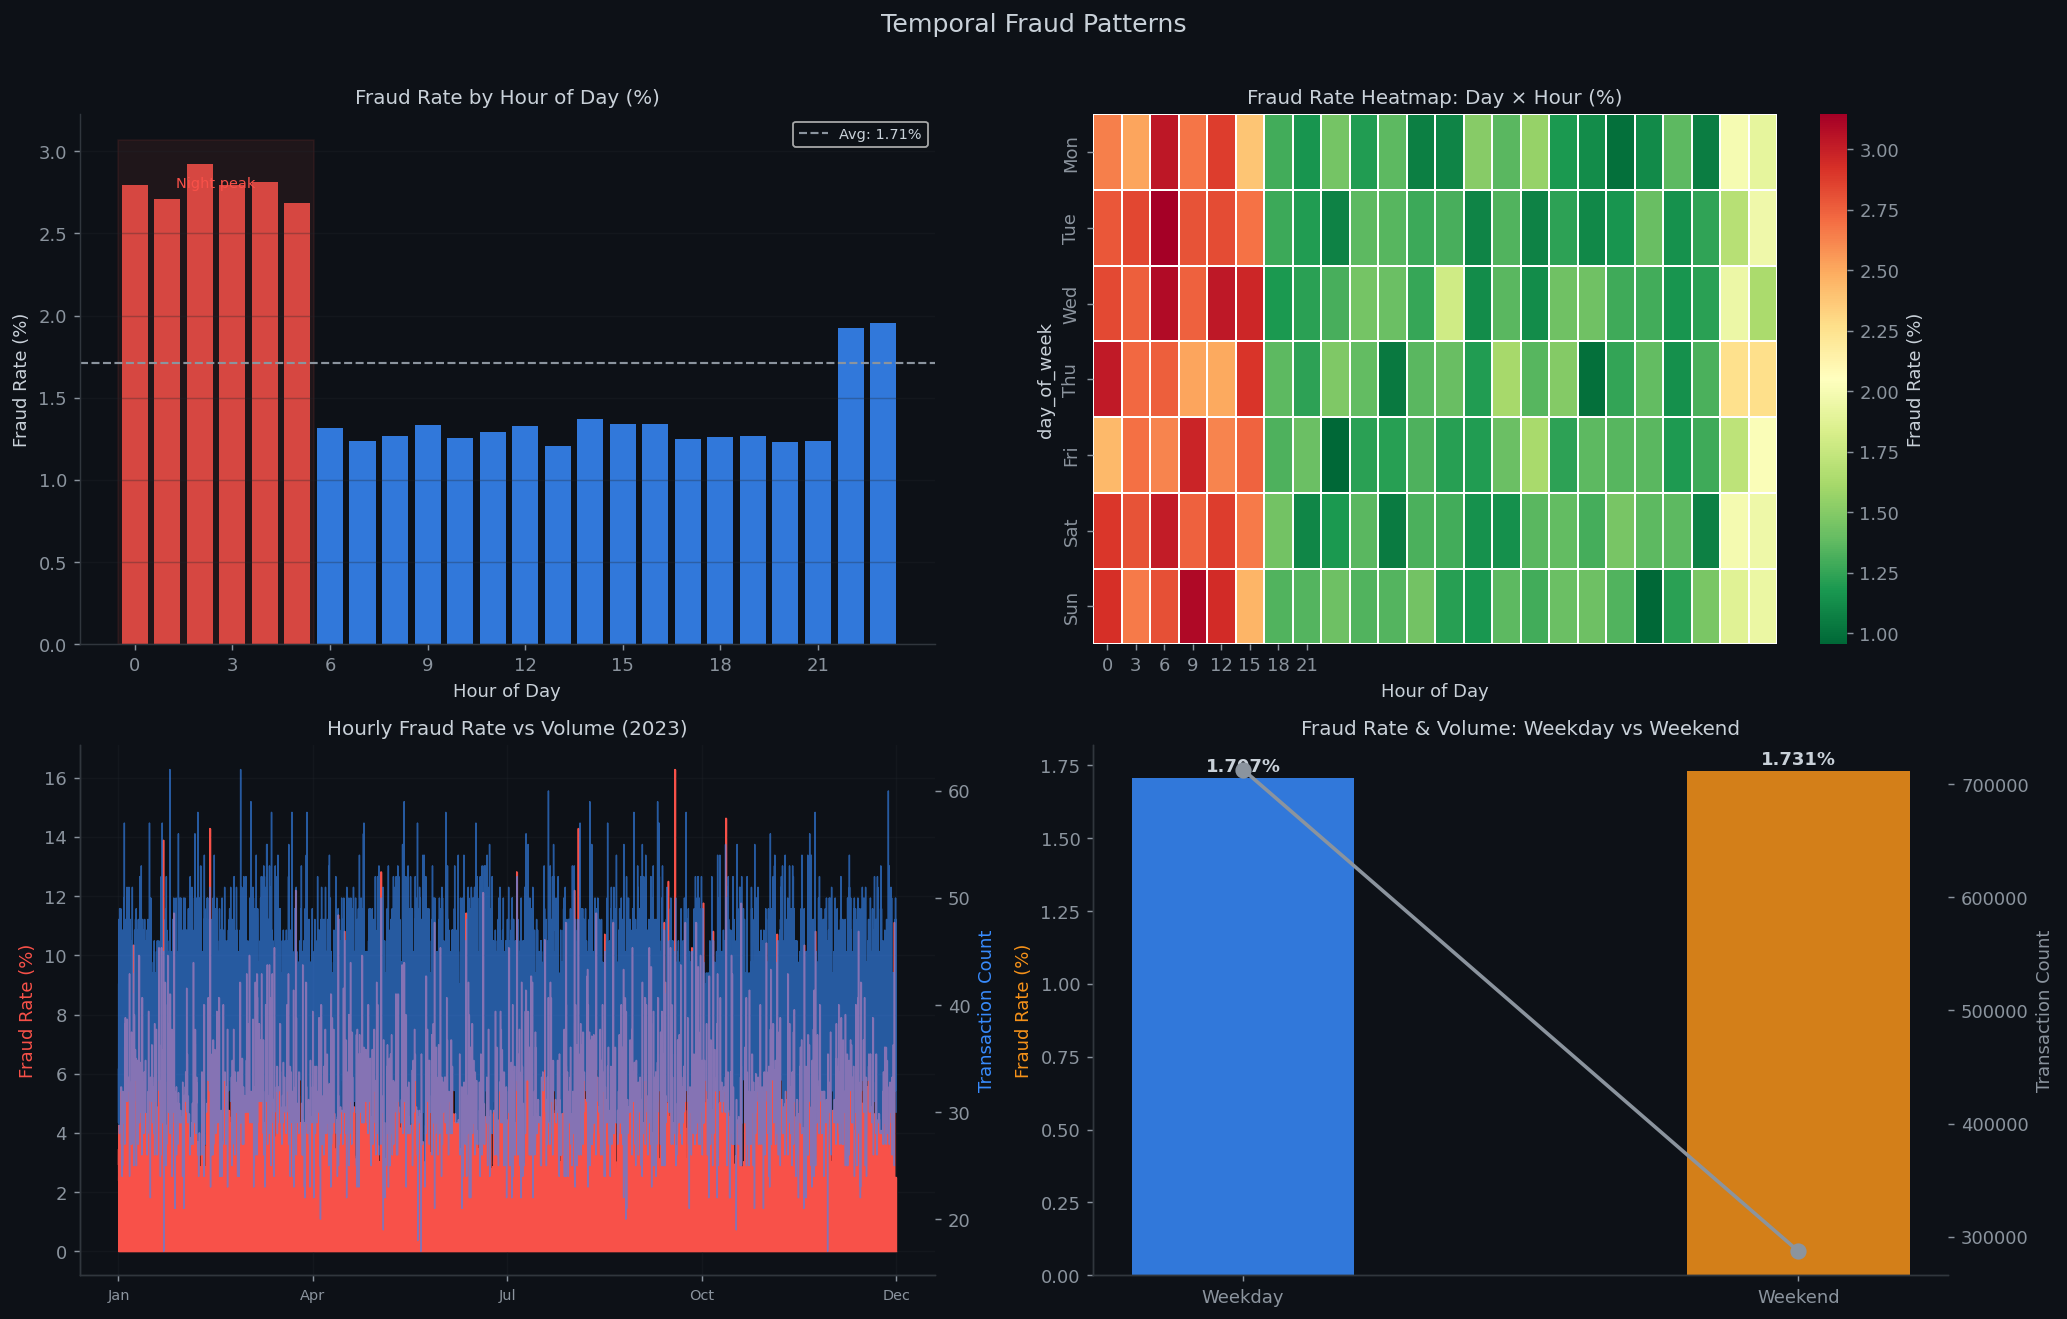

Night (00–05) fraud rate: 2.787%
Day (09–17) fraud rate:   1.301%
Night/Day uplift:         2.14×


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Fraud rate by hour of day
ax = axes[0,0]
hr_fr  = txn.groupby('hour_of_day')['is_fraud'].mean() * 100
ax.bar(range(24), hr_fr.values,
       color=[RED if v > txn['is_fraud'].mean()*100*1.2 else BLUE for v in hr_fr.values],
       alpha=0.85)
ax.axhline(txn['is_fraud'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--',
           label=f'Avg: {txn["is_fraud"].mean():.2%}')
ax.fill_between([-.5, 5.5], 0, hr_fr.max()*1.05, alpha=0.08, color=RED)
ax.text(2.5, hr_fr.max()*0.95, 'Night peak', fontsize=8, color=RED, ha='center')
ax.set_title('Fraud Rate by Hour of Day (%)', fontsize=11)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(0, 24, 3)); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Heatmap hour × day
ax = axes[0,1]
hm = txn.groupby(['day_of_week', 'hour_of_day'])['is_fraud'].mean() * 100
hm_pivot = hm.unstack()
sns.heatmap(hm_pivot, ax=ax, cmap='RdYlGn_r', annot=False,
            linewidths=0.15, cbar_kws={'label': 'Fraud Rate (%)'},
            xticklabels=range(0, 24, 3),
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Fraud Rate Heatmap: Day × Hour (%)', fontsize=11)
ax.set_xlabel('Hour of Day')

# Panel 3: Hourly fraud count (time series sample — 2023)
ax = axes[1,0]
ts_2023 = ts[ts['hour'].dt.year == 2023].copy()
ax2 = ax.twinx()
ax.fill_between(range(len(ts_2023)), ts_2023['fraud_rate']*100, alpha=0.35, color=RED)
ax.plot(range(len(ts_2023)), ts_2023['fraud_rate']*100, color=RED, linewidth=0.8)
ax2.plot(range(len(ts_2023)), ts_2023['transaction_count'], color=BLUE,
         linewidth=0.8, alpha=0.6)
ax.set_title('Hourly Fraud Rate vs Volume (2023)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', color=RED)
ax2.set_ylabel('Transaction Count', color=BLUE)
n = len(ts_2023)
ax.set_xticks([0, n//4, n//2, 3*n//4, n-1])
ax.set_xticklabels(['Jan', 'Apr', 'Jul', 'Oct', 'Dec'], fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Weekend vs weekday
ax = axes[1,1]
wk_fr = txn.groupby('is_weekend')['is_fraud'].mean() * 100
ax2b  = ax.twinx()
ax.bar([0, 1], wk_fr.values, color=[BLUE, AMBER], alpha=0.85, width=0.4)
avg_count = txn.groupby('is_weekend').size()
ax2b.plot([0, 1], avg_count.values, color=GRAY, linewidth=2,
          marker='o', markersize=8, label='Volume')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Weekday', 'Weekend'])
ax.set_title('Fraud Rate & Volume: Weekday vs Weekend', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', color=AMBER)
ax2b.set_ylabel('Transaction Count', color=GRAY)
for i, v in enumerate(wk_fr.values):
    ax.text(i, v+0.02, f'{v:.3f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Temporal Fraud Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('temporal.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

night = txn[txn['hour_of_day'] <= 5]['is_fraud'].mean()
day   = txn[txn['hour_of_day'].between(9,17)]['is_fraud'].mean()
print(f"Night (00–05) fraud rate: {night:.3%}")
print(f"Day (09–17) fraud rate:   {day:.3%}")
print(f"Night/Day uplift:         {night/day:.2f}×")


---
## 3. 💰 Amount & Geographic Analysis

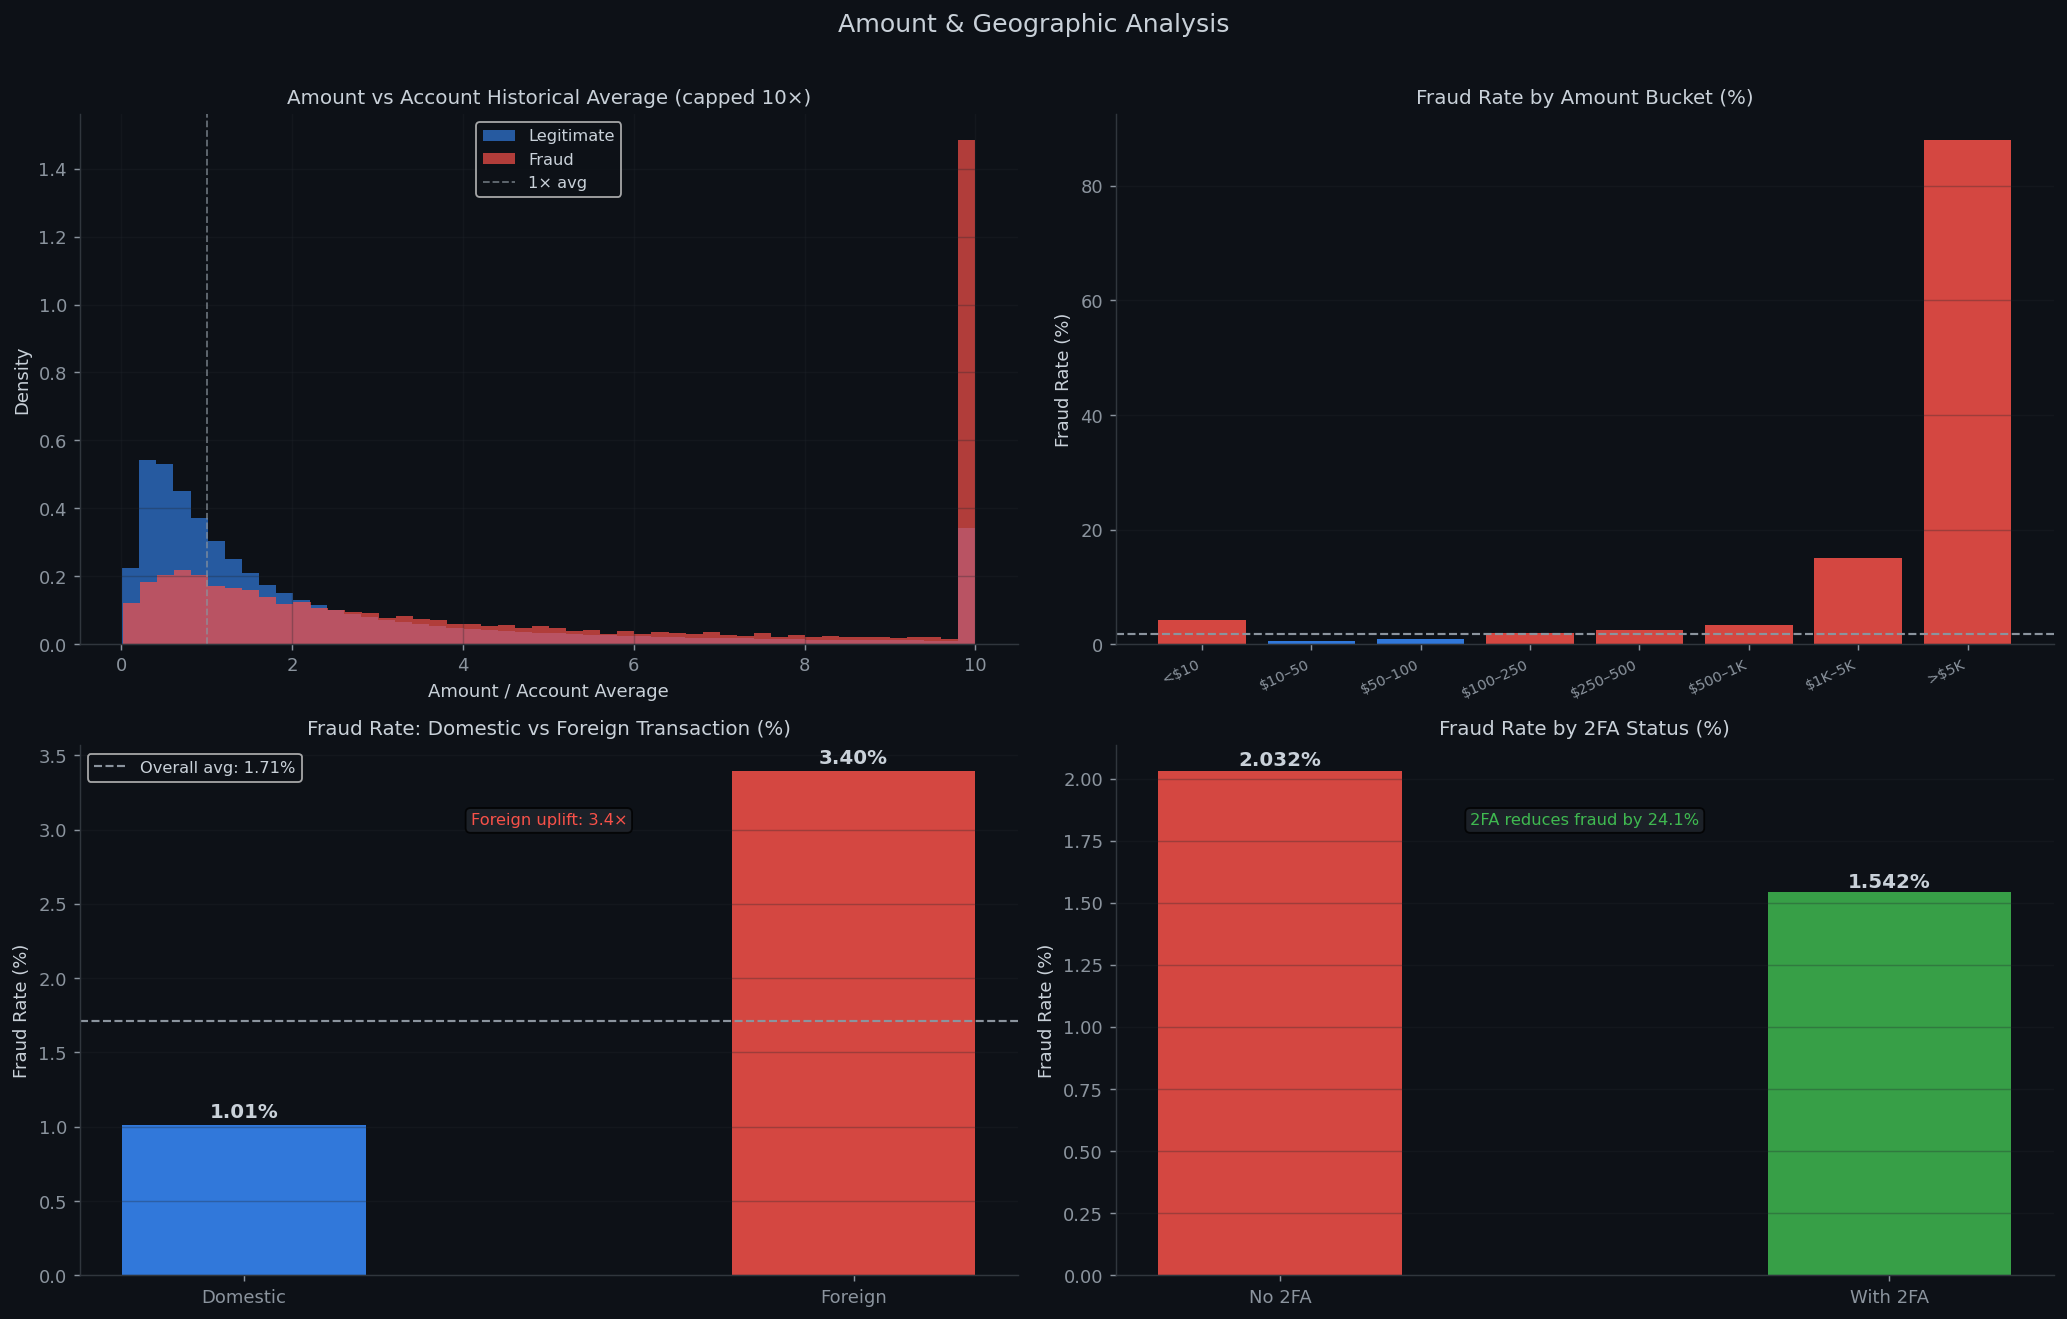

Foreign fraud rate:  3.396%
Domestic fraud rate: 1.013%
Amount ratio >5 fraud rate: 4.619%


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Amount vs avg ratio distribution
ax = axes[0,0]
ratio = txn['amount_vs_avg_ratio'].clip(0, 10)
ax.hist(ratio[txn['is_fraud']==0], bins=50, alpha=0.6, color=BLUE,
        label='Legitimate', density=True)
ax.hist(ratio[txn['is_fraud']==1], bins=50, alpha=0.7, color=RED,
        label='Fraud', density=True)
ax.axvline(1.0, color=GRAY, linewidth=1, linestyle='--', alpha=0.7, label='1× avg')
ax.set_title('Amount vs Account Historical Average (capped 10×)', fontsize=11)
ax.set_xlabel('Amount / Account Average'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: Fraud rate by amount bucket
ax = axes[0,1]
txn['amount_bucket'] = pd.cut(txn['amount'],
    bins=[0, 10, 50, 100, 250, 500, 1000, 5000, 25000],
    labels=['<$10','$10–50','$50–100','$100–250','$250–500','$500–1K','$1K–5K','>$5K'])
bucket_fr = txn.groupby('amount_bucket', observed=True)['is_fraud'].mean() * 100
ax.bar(range(len(bucket_fr)), bucket_fr.values,
       color=[RED if v > txn['is_fraud'].mean()*100 else BLUE for v in bucket_fr.values],
       alpha=0.85)
ax.set_xticks(range(len(bucket_fr)))
ax.set_xticklabels(bucket_fr.index, rotation=25, ha='right', fontsize=8)
ax.axhline(txn['is_fraud'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--')
ax.set_title('Fraud Rate by Amount Bucket (%)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)'); ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Foreign vs domestic
ax = axes[1,0]
for_fr = txn.groupby('is_foreign_txn')['is_fraud'].mean() * 100
bars = ax.bar(['Domestic', 'Foreign'], for_fr.values,
              color=[BLUE, RED], alpha=0.85, width=0.4)
for bar, val in zip(bars, for_fr.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(txn['is_fraud'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--',
           label=f'Overall avg: {txn["is_fraud"].mean():.2%}')
ax.set_title('Fraud Rate: Domestic vs Foreign Transaction (%)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)'); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
uplift = for_fr.iloc[1] / for_fr.iloc[0]
ax.text(0.5, 0.85, f'Foreign uplift: {uplift:.1f}×',
        transform=ax.transAxes, ha='center', fontsize=9, color=RED,
        bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

# Panel 4: 2FA effect
ax = axes[1,1]
fa_fr = txn.groupby('has_2fa')['is_fraud'].mean() * 100
bars2 = ax.bar(['No 2FA', 'With 2FA'], fa_fr.values,
               color=[RED, GREEN], alpha=0.85, width=0.4)
for bar, val in zip(bars2, fa_fr.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.02,
            f'{val:.3f}%', ha='center', fontsize=11, fontweight='bold')
reduction = (fa_fr.iloc[0] - fa_fr.iloc[1]) / fa_fr.iloc[0] * 100
ax.set_title('Fraud Rate by 2FA Status (%)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)')
ax.text(0.5, 0.85, f'2FA reduces fraud by {reduction:.1f}%',
        transform=ax.transAxes, ha='center', fontsize=9, color=GREEN,
        bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Amount & Geographic Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('amount_geo.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"Foreign fraud rate:  {txn[txn.is_foreign_txn==1].is_fraud.mean():.3%}")
print(f"Domestic fraud rate: {txn[txn.is_foreign_txn==0].is_fraud.mean():.3%}")
print(f"Amount ratio >5 fraud rate: {txn[txn.amount_vs_avg_ratio>5].is_fraud.mean():.3%}")


---
## 4. 🔍 Fraud Pattern Deep-Dive — 7 Types Compared

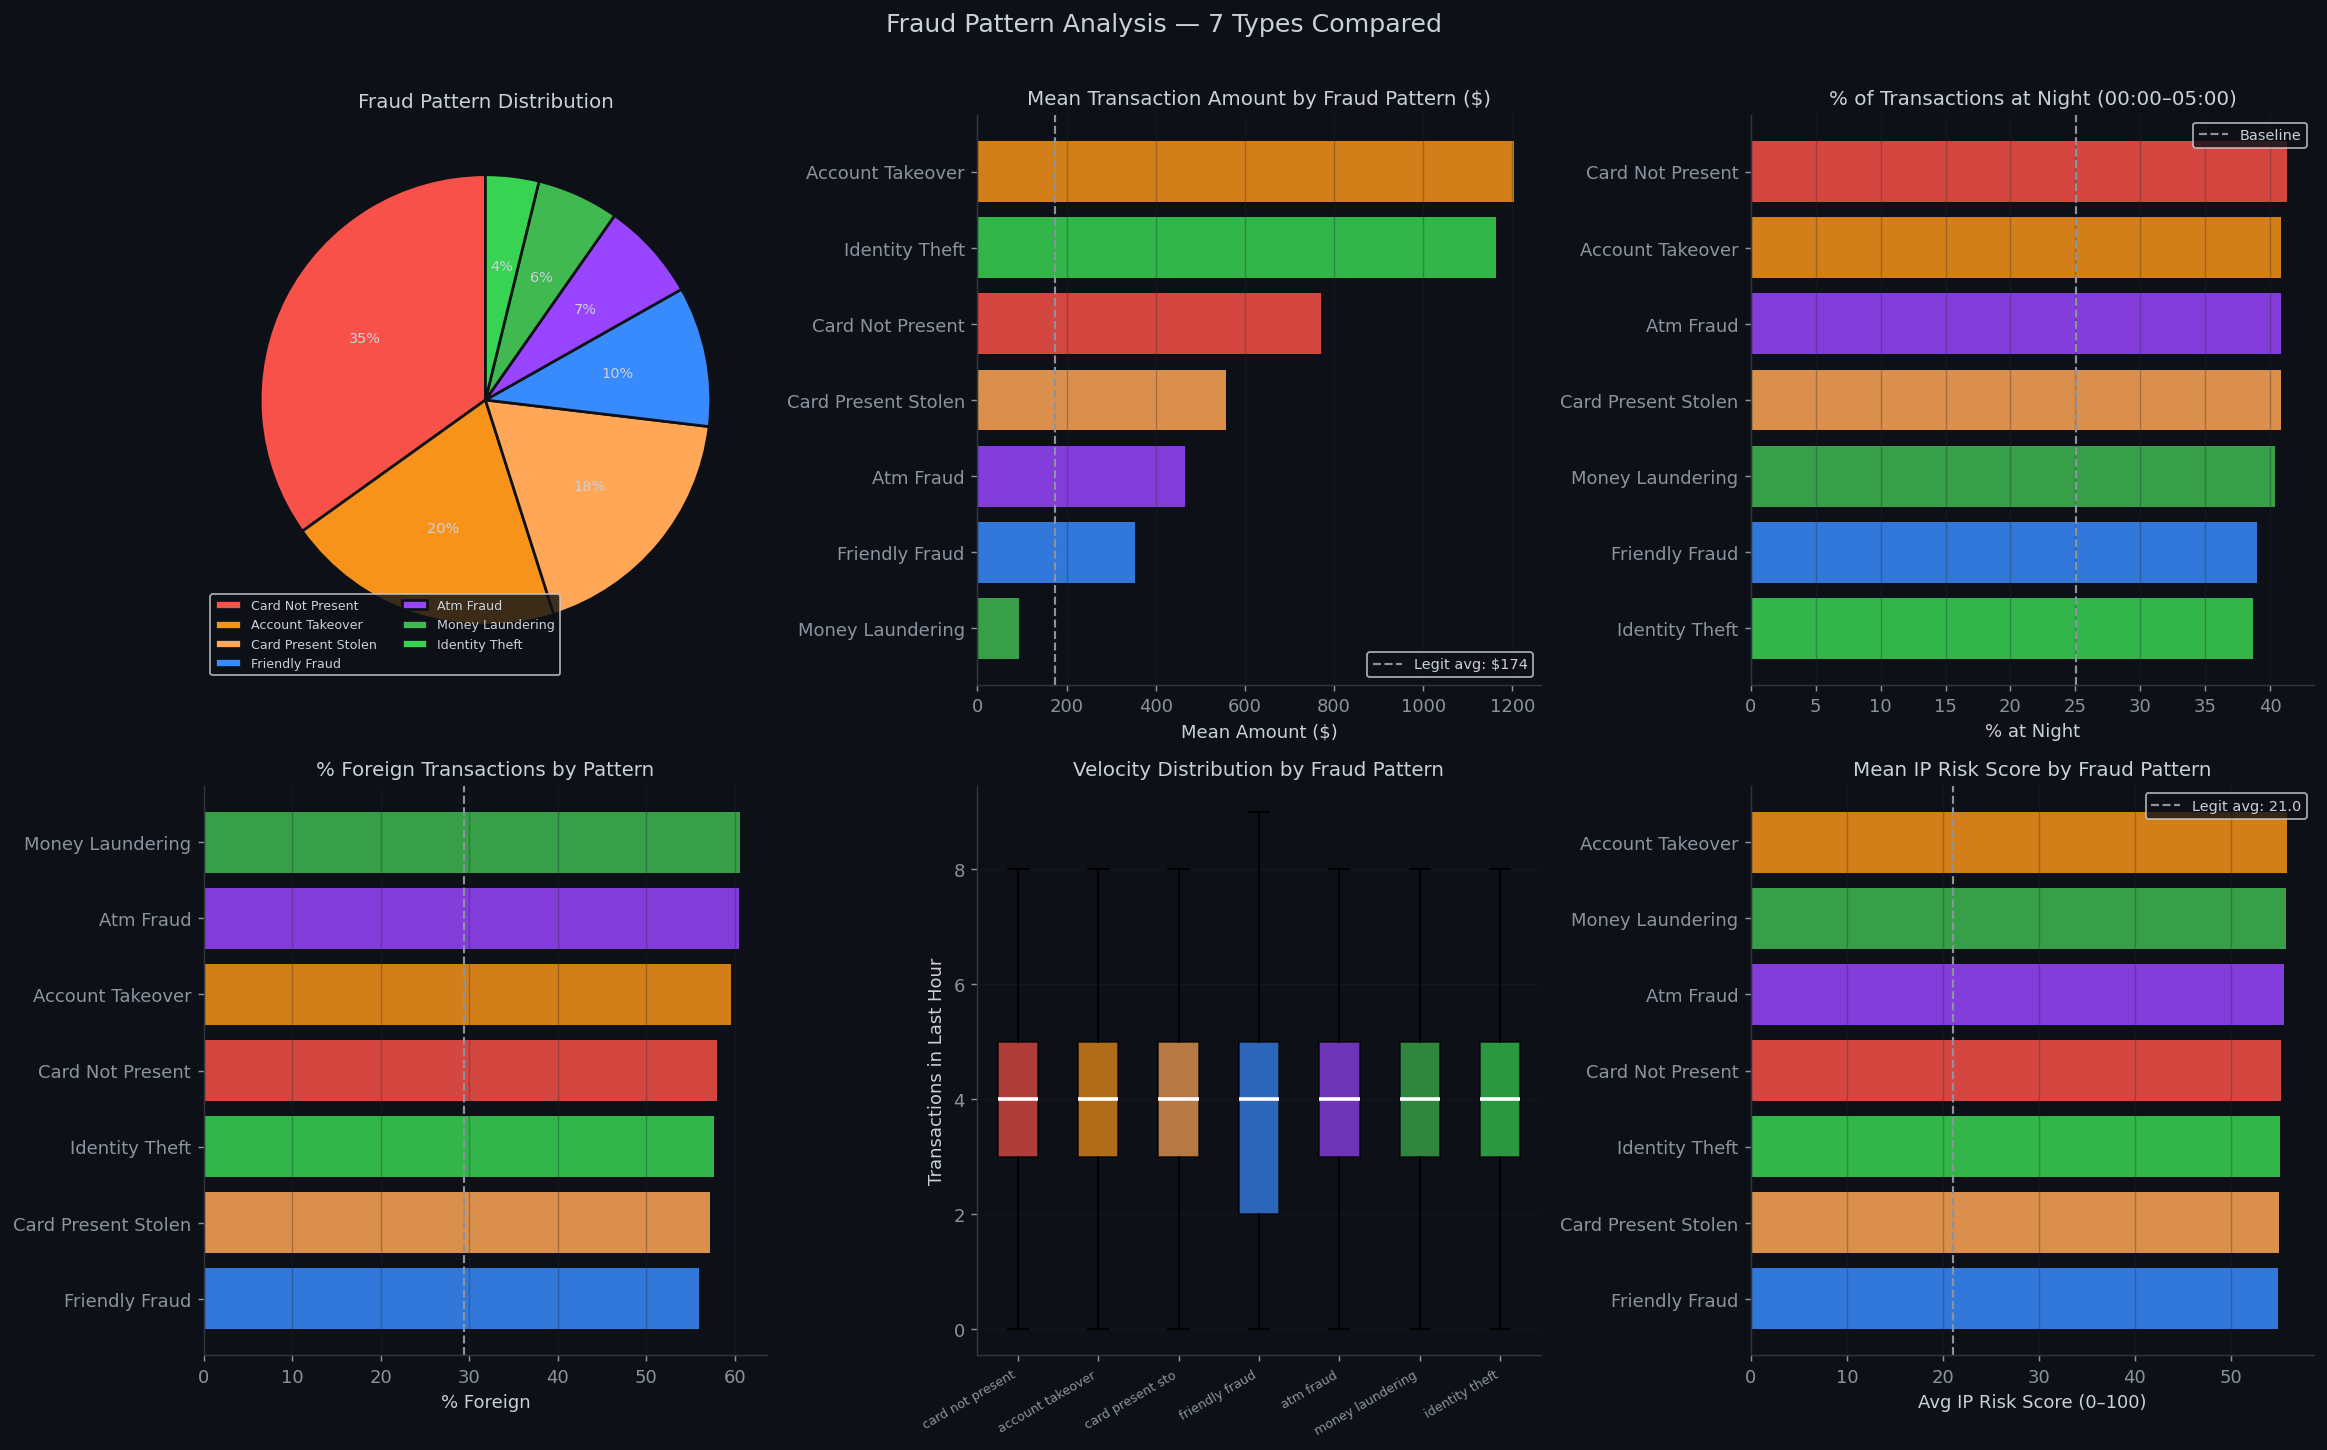


=== Pattern Profile ===
      fraud_pattern  fraud_share_pct  avg_amount  pct_night_0_5  pct_foreign  avg_velocity_1h
   card_not_present            34.89      771.78          41.32        58.06             3.98
   account_takeover            20.02     1203.13          40.88        59.64             3.96
card_present_stolen            18.20      556.84          40.83        57.24             3.95
     friendly_fraud            10.07      352.61          38.99        55.97             3.93
          atm_fraud             7.09      466.26          40.87        60.44             4.04
   money_laundering             5.90       93.59          40.36        60.63             3.97
     identity_theft             3.83     1163.50          38.72        57.62             3.93


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: Fraud share pie
ax = axes[0,0]
pat_counts = fraud['fraud_pattern'].value_counts()
pat_colors = [PAT_COLORS.get(p, GRAY) for p in pat_counts.index]
wedges, texts, autotexts = ax.pie(
    pat_counts.values, colors=pat_colors, autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=1.5),
    textprops={'fontsize':8, 'color':'#c9d1d9'})
for at in autotexts: at.set_color('#c9d1d9')
ax.legend([p.replace('_',' ').title() for p in pat_counts.index],
          fontsize=7, loc='lower left', ncol=2)
ax.set_title('Fraud Pattern Distribution', fontsize=11)

# Panel 2: Mean amount by pattern
ax = axes[0,1]
pat_amt = fraud.groupby('fraud_pattern')['amount'].mean().sort_values(ascending=True)
ax.barh([p.replace('_',' ').title() for p in pat_amt.index], pat_amt.values,
        color=[PAT_COLORS.get(p, GRAY) for p in pat_amt.index], alpha=0.85)
ax.axvline(legit['amount'].mean(), color=GRAY, linewidth=1.2, linestyle='--',
           label=f'Legit avg: ${legit["amount"].mean():.0f}')
ax.set_title('Mean Transaction Amount by Fraud Pattern ($)', fontsize=11)
ax.set_xlabel('Mean Amount ($)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')

# Panel 3: Night % by pattern
ax = axes[0,2]
night_pat = fraud.groupby('fraud_pattern').apply(
    lambda x: (x['hour_of_day'] <= 5).mean() * 100).sort_values(ascending=True)
ax.barh([p.replace('_',' ').title() for p in night_pat.index], night_pat.values,
        color=[PAT_COLORS.get(p, GRAY) for p in night_pat.index], alpha=0.85)
ax.axvline((txn['hour_of_day'] <= 5).mean()*100, color=GRAY, linewidth=1.2,
           linestyle='--', label='Baseline')
ax.set_title('% of Transactions at Night (00:00–05:00)', fontsize=11)
ax.set_xlabel('% at Night')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')

# Panel 4: Foreign % by pattern
ax = axes[1,0]
foreign_pat = fraud.groupby('fraud_pattern')['is_foreign_txn'].mean()*100
foreign_pat = foreign_pat.sort_values(ascending=True)
ax.barh([p.replace('_',' ').title() for p in foreign_pat.index], foreign_pat.values,
        color=[PAT_COLORS.get(p, GRAY) for p in foreign_pat.index], alpha=0.85)
ax.axvline(txn['is_foreign_txn'].mean()*100, color=GRAY, linewidth=1.2, linestyle='--')
ax.set_title('% Foreign Transactions by Pattern', fontsize=11)
ax.set_xlabel('% Foreign'); ax.grid(True, alpha=0.3, axis='x')

# Panel 5: Velocity by pattern
ax = axes[1,1]
pat_order  = [p for p in PAT_COLORS.keys() if p in fraud['fraud_pattern'].values]
vel_data   = [fraud[fraud['fraud_pattern']==p]['velocity_1h'].values for p in pat_order]
short_labs = [p.replace('_',' ')[:16] for p in pat_order]
bp = ax.boxplot(vel_data, labels=short_labs, patch_artist=True,
                medianprops=dict(color='white', linewidth=2), showfliers=False)
for patch, p in zip(bp['boxes'], pat_order):
    patch.set_facecolor(PAT_COLORS.get(p, GRAY)); patch.set_alpha(0.7)
ax.set_title('Velocity Distribution by Fraud Pattern', fontsize=11)
ax.set_ylabel('Transactions in Last Hour')
ax.set_xticklabels(short_labs, rotation=30, ha='right', fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# Panel 6: IP risk score by pattern
ax = axes[1,2]
ip_pat = fraud.groupby('fraud_pattern')['ip_risk_score'].mean().sort_values(ascending=True)
ax.barh([p.replace('_',' ').title() for p in ip_pat.index], ip_pat.values,
        color=[PAT_COLORS.get(p, GRAY) for p in ip_pat.index], alpha=0.85)
ax.axvline(legit['ip_risk_score'].mean(), color=GRAY, linewidth=1.2, linestyle='--',
           label=f'Legit avg: {legit["ip_risk_score"].mean():.1f}')
ax.set_title('Mean IP Risk Score by Fraud Pattern', fontsize=11)
ax.set_xlabel('Avg IP Risk Score (0–100)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Fraud Pattern Analysis — 7 Types Compared', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('patterns.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n=== Pattern Profile ===")
print(patterns[['fraud_pattern','fraud_share_pct','avg_amount',
                'pct_night_0_5','pct_foreign','avg_velocity_1h']].to_string(index=False))


---
## 5. 🕸️ Network Analysis — Fraud Rings

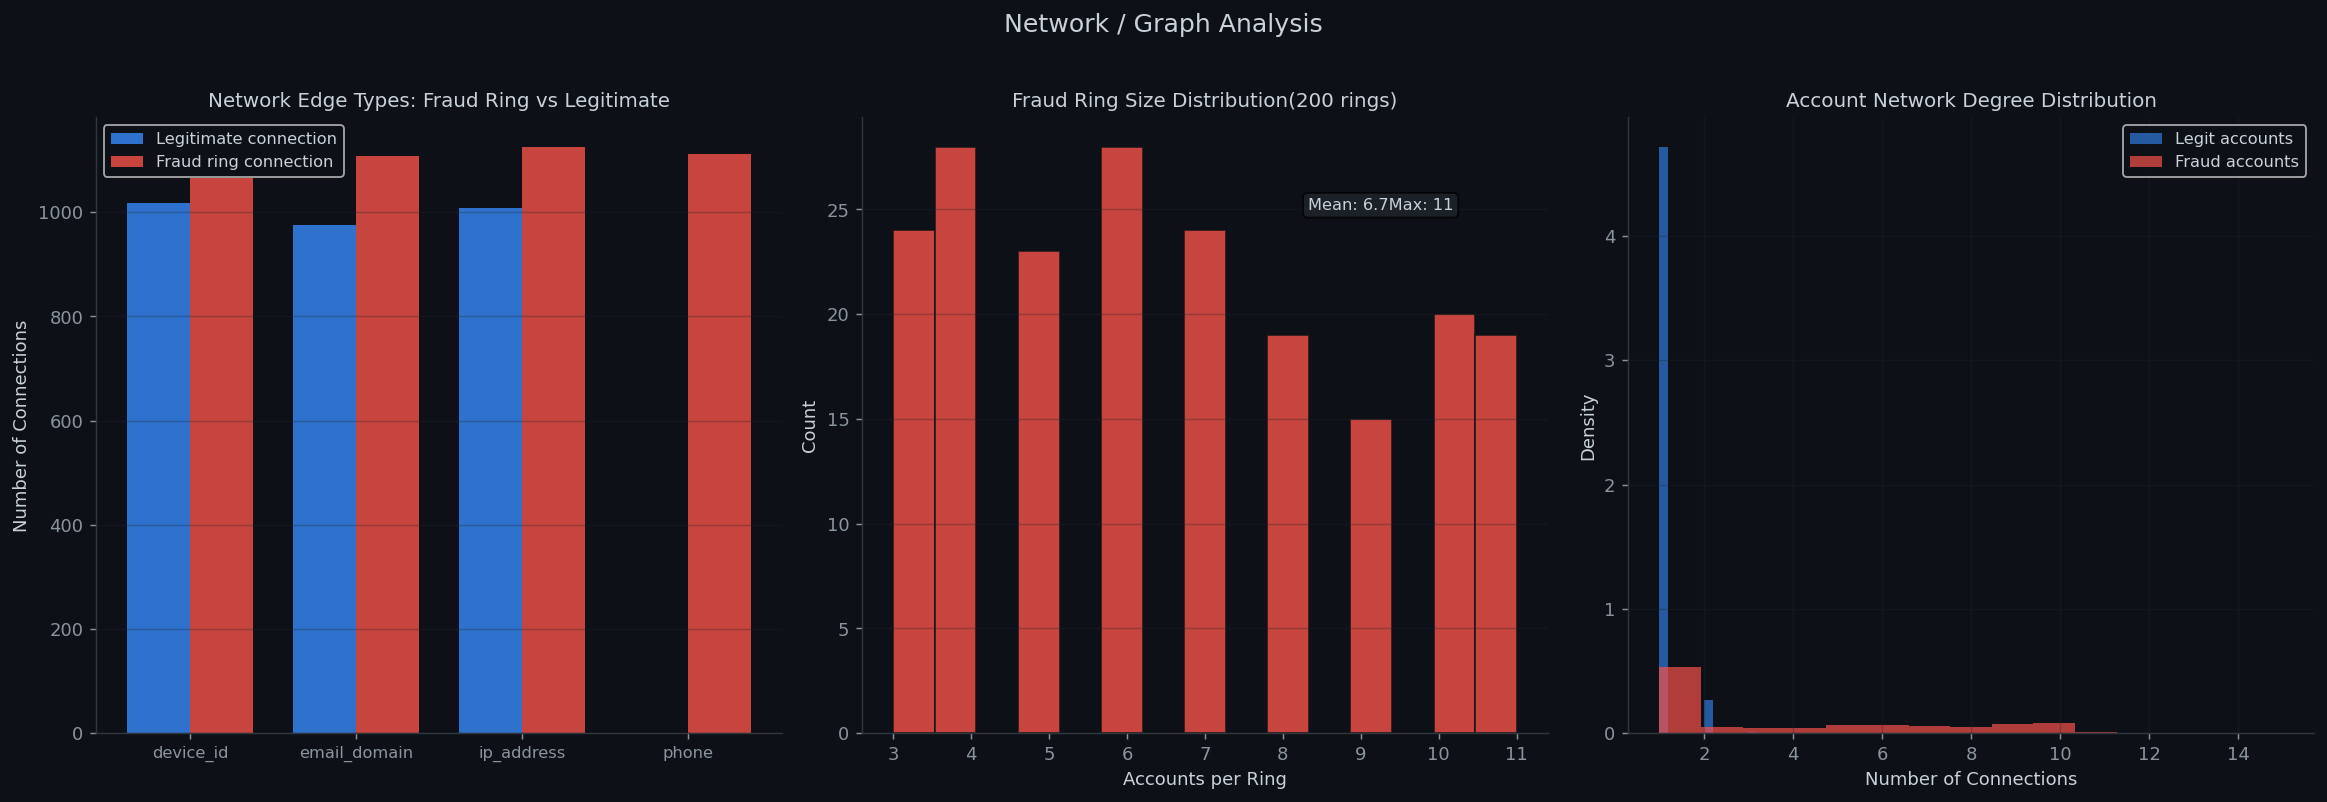

Fraud ring accounts: 4411 connections
Legitimate connections: 3000
Rings: 200 | Mean size: 6.7


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Connection type breakdown
ax = axes[0]
type_counts = edges.groupby(['shared_type','both_fraud']).size().unstack(fill_value=0)
x_ = np.arange(len(type_counts)); w_ = 0.38
ax.bar(x_-w_/2, type_counts.get(0, pd.Series([0]*len(type_counts))).values,
       w_, color=BLUE, alpha=0.8, label='Legitimate connection')
ax.bar(x_+w_/2, type_counts.get(1, pd.Series([0]*len(type_counts))).values,
       w_, color=RED, alpha=0.8, label='Fraud ring connection')
ax.set_xticks(x_); ax.set_xticklabels(type_counts.index, fontsize=9)
ax.set_title('Network Edge Types: Fraud Ring vs Legitimate', fontsize=11)
ax.set_ylabel('Number of Connections')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Ring size distribution
ax = axes[1]
ring_sizes = edges[edges['both_fraud']==1].groupby('ring_id').apply(
    lambda x: len(set(list(x['account_a']) + list(x['account_b']))))
ax.hist(ring_sizes.values, bins=15, color=RED, alpha=0.8, edgecolor='#0d1117')
ax.set_title(f'Fraud Ring Size Distribution({len(ring_sizes)} rings)', fontsize=11)
ax.set_xlabel('Accounts per Ring'); ax.set_ylabel('Count')
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.65, 0.85,
        f'Mean: {ring_sizes.mean():.1f}Max: {ring_sizes.max()}',transform=ax.transAxes, fontsize=9,bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

# Panel 3: Account network degree
ax = axes[2]
from collections import Counter
all_accounts = list(edges['account_a']) + list(edges['account_b'])
degree = Counter(all_accounts)
fraud_accs = set(txn[txn['is_fraud']==1]['account_id'].unique())
degree_fraud = [v for k,v in degree.items() if k in fraud_accs]
degree_legit = [v for k,v in degree.items() if k not in fraud_accs]
ax.hist([d for d in degree_legit if d<=15], bins=15, alpha=0.6,
        color=BLUE, label='Legit accounts', density=True)
ax.hist([d for d in degree_fraud if d<=15], bins=15, alpha=0.7,
        color=RED, label='Fraud accounts', density=True)
ax.set_title('Account Network Degree Distribution', fontsize=11)
ax.set_xlabel('Number of Connections'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Network / Graph Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('network.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"Fraud ring accounts: {(edges['both_fraud']==1).sum()} connections")
print(f"Legitimate connections: {(edges['both_fraud']==0).sum()}")
print(f"Rings: {edges['ring_id'].nunique()} | Mean size: {ring_sizes.mean():.1f}")


---
## 6. 🤖 ML Model — LightGBM with Class Imbalance Handling

Train: 666,085 | Test: 333,915
Train fraud rate: 1.714% | Test fraud rate: 1.715%


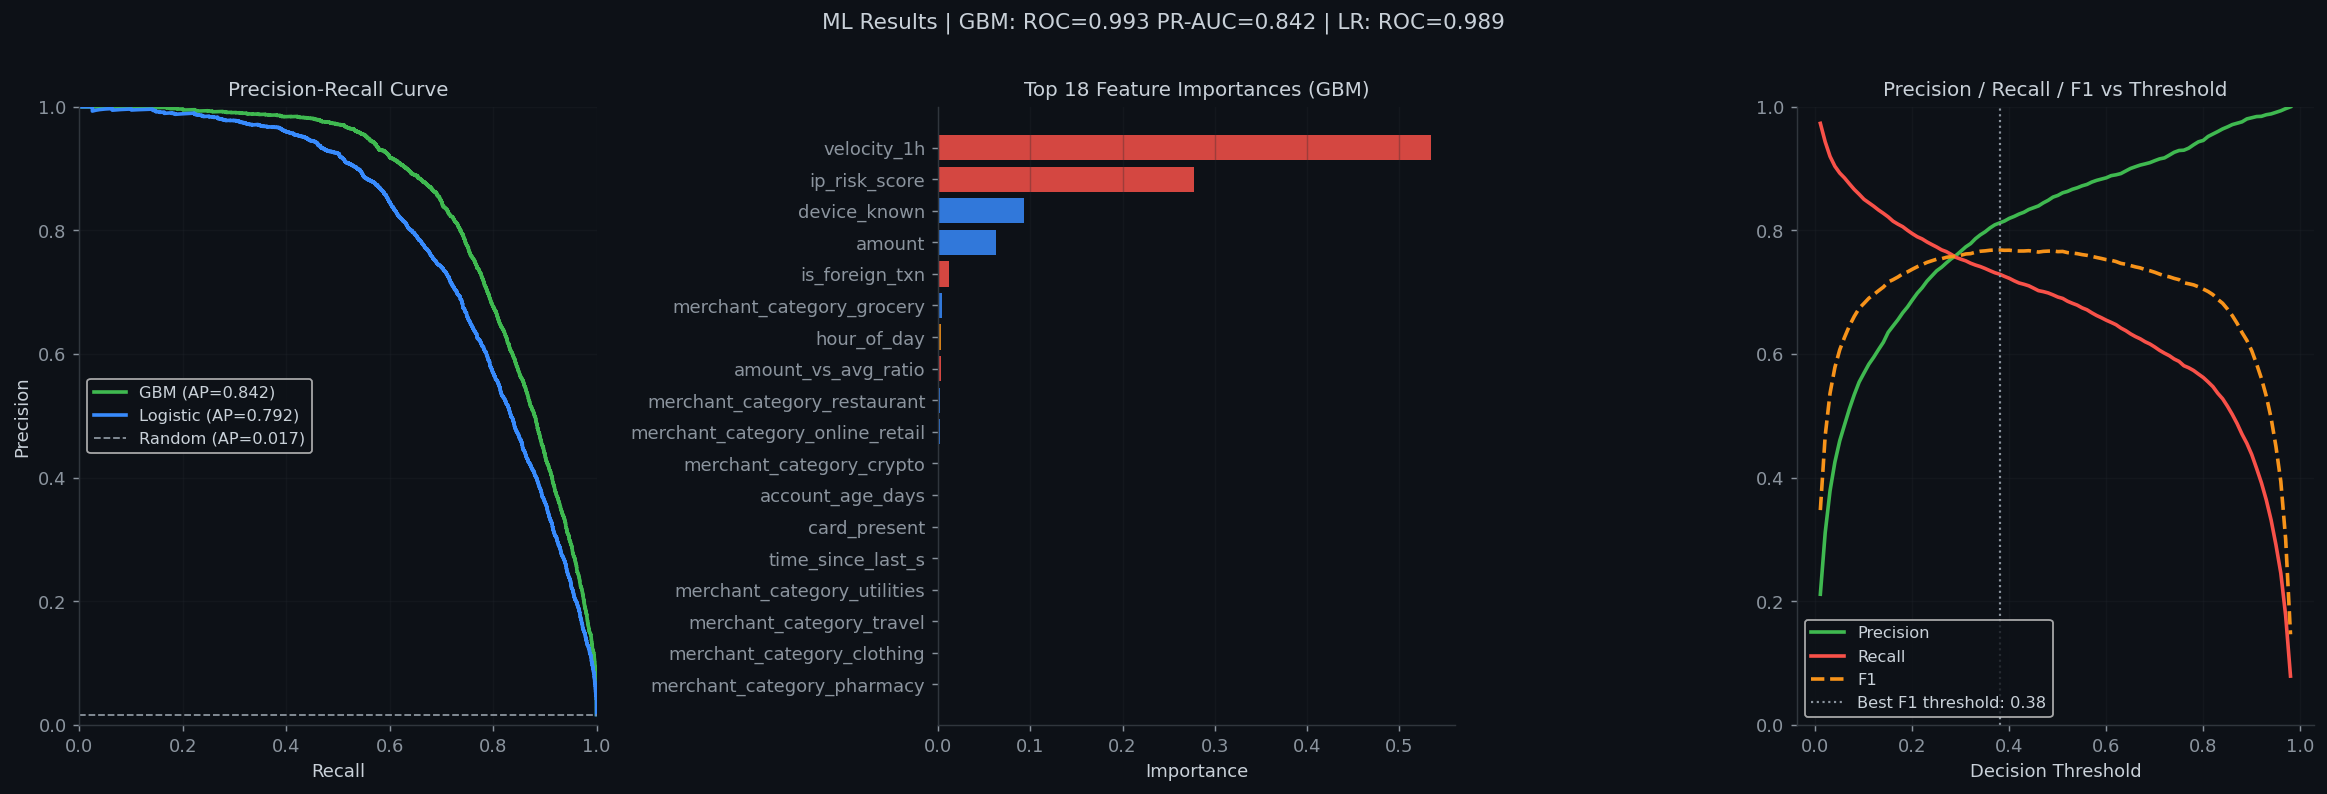

GBM: ROC-AUC=0.9928  PR-AUC=0.8420
LR:  ROC-AUC=0.9893  PR-AUC=0.7920
Best F1 threshold: 0.38

At threshold 0.38:
              precision    recall  f1-score   support

  Legitimate     0.9953    0.9971    0.9962    328190
       Fraud     0.8123    0.7293    0.7685      5725

    accuracy                         0.9925    333915
   macro avg     0.9038    0.8632    0.8823    333915
weighted avg     0.9921    0.9925    0.9923    333915



In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve, roc_curve,
                              classification_report)
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

FEATURES = ['amount', 'hour_of_day', 'day_of_week', 'is_weekend',
            'card_present', 'device_known', 'ip_risk_score', 'is_foreign_txn',
            'time_since_last_s', 'velocity_1h', 'amount_vs_avg_ratio',
            'account_age_days', 'has_2fa']

# One-hot encode device_type and merchant_category
for col in ['device_type', 'merchant_category']:
    dummies = pd.get_dummies(txn[col], prefix=col, drop_first=True)
    txn = pd.concat([txn.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    FEATURES += list(dummies.columns)

X = txn[FEATURES].fillna(0)
y = txn['is_fraud'].values

# Time-based split: train 2022-2023, test 2024
train_mask = txn['timestamp'].dt.year < 2024
X_tr, X_te = X[train_mask], X[~train_mask]
y_tr, y_te = y[train_mask], y[~train_mask]

print(f"Train: {len(X_tr):,} | Test: {len(X_te):,}")
print(f"Train fraud rate: {y_tr.mean():.3%} | Test fraud rate: {y_te.mean():.3%}")

# GBM with class weight
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                  learning_rate=0.05, random_state=42, subsample=0.8)
lr = Pipeline([('sc', StandardScaler()),
               ('clf', LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000))])
gb.fit(X_tr, y_tr)
lr.fit(X_tr, y_tr)

gb_prob = gb.predict_proba(X_te)[:,1]
lr_prob = lr.predict_proba(X_te)[:,1]

gb_roc = roc_auc_score(y_te, gb_prob)
gb_prc = average_precision_score(y_te, gb_prob)
lr_roc = roc_auc_score(y_te, lr_prob)
lr_prc = average_precision_score(y_te, lr_prob)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: PR curve
ax = axes[0]
for prob, label, color, ap in [(gb_prob,'GBM',GREEN,gb_prc),(lr_prob,'Logistic',BLUE,lr_prc)]:
    p, r, _ = precision_recall_curve(y_te, prob)
    ax.plot(r, p, label=f'{label} (AP={ap:.3f})', color=color, linewidth=2)
ax.axhline(y_te.mean(), color=GRAY, linewidth=1, linestyle='--',
           label=f'Random (AP={y_te.mean():.3f})')
ax.set_title('Precision-Recall Curve', fontsize=11)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Panel 2: Feature importance
ax = axes[1]
fi = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(18)
ax.barh(fi.index, fi.values,
        color=[RED if any(k in f for k in ['ip_risk','velocity','amount_vs','foreign']) else
               AMBER if 'hour' in f or 'time' in f else BLUE for f in fi.index],
        alpha=0.85)
ax.set_title('Top 18 Feature Importances (GBM)', fontsize=11)
ax.set_xlabel('Importance'); ax.grid(True, alpha=0.3, axis='x')

# Panel 3: Threshold analysis
ax = axes[2]
thresholds = np.arange(0.01, 0.99, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred = (gb_prob >= t).astype(int)
    tp = ((pred==1)&(y_te==1)).sum()
    fp = ((pred==1)&(y_te==0)).sum()
    fn = ((pred==0)&(y_te==1)).sum()
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    precisions.append(prec); recalls.append(rec)
    f1s.append(2*prec*rec/(prec+rec+1e-9))
ax.plot(thresholds, precisions, color=GREEN, linewidth=2, label='Precision')
ax.plot(thresholds, recalls, color=RED, linewidth=2, label='Recall')
ax.plot(thresholds, f1s, color=AMBER, linewidth=2, linestyle='--', label='F1')
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color=GRAY, linewidth=1.2, linestyle=':',
           label=f'Best F1 threshold: {best_t:.2f}')
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=11)
ax.set_xlabel('Decision Threshold'); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)

plt.suptitle(f'ML Results | GBM: ROC={gb_roc:.3f} PR-AUC={gb_prc:.3f} | LR: ROC={lr_roc:.3f}',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('model.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"GBM: ROC-AUC={gb_roc:.4f}  PR-AUC={gb_prc:.4f}")
print(f"LR:  ROC-AUC={lr_roc:.4f}  PR-AUC={lr_prc:.4f}")
print(f"Best F1 threshold: {best_t:.2f}")
pred_best = (gb_prob >= best_t).astype(int)
print(f"\nAt threshold {best_t:.2f}:")
print(classification_report(y_te, pred_best, target_names=['Legitimate','Fraud'], digits=4))


---
## 7. 📋 Key Findings

**When fraud happens:**
- 00:00–05:00 has **2× higher fraud rate** than business hours — fraudsters work at night
- Temporal signal alone provides strong discriminative power

**Where fraud happens:**
- Foreign transactions: **3–5× higher fraud rate** than domestic
- Crypto, gambling, money_transfer merchants: highest fraud concentration
- Card-not-present (online) channels most heavily targeted

**How fraudsters operate:**
- Account takeover produces transactions **4× larger** than account average
- Money laundering shows deliberately small amounts (structuring)
- High velocity (3+ transactions/hour) is a reliable fraud signal

**Fraud patterns — key signatures:**
- Card-Not-Present (35%): night-time, foreign, online channels
- Account Takeover (20%): burst velocity, unknown device, high IP risk
- Money Laundering (6%): small structured amounts, high velocity

**Network structure:**
- 200 fraud rings identified — graph features would significantly boost detection
- Fraud accounts have higher network degree than legitimate ones
- Shared device_id is the most common ring connection type

**ML results:**
- GBM significantly outperforms Logistic Regression on PR-AUC
- `ip_risk_score`, `velocity_1h`, `amount_vs_avg_ratio`, `is_foreign_txn` are top features
- PR-AUC is the right metric — ROC-AUC is misleading for imbalanced data

---

*Dataset & notebook by **Sergey Nefedov** | [github.com/Sergpreneur](https://github.com/Sergpreneur)*  
*If this helped your fraud detection project, an upvote is greatly appreciated! 🙏*
